In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# Load Dataset
# =========================

df = pd.read_csv("data.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())



First 5 Rows:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated         

In [24]:
# =========================
# Data Preprocessing
# =========================

# Drop unnecessary columns
df.drop(["date", "street", "country"], axis=1, inplace=True)

# Encode categorical columns
city_encoder = LabelEncoder()
state_encoder = LabelEncoder()

df["city"] = city_encoder.fit_transform(df["city"])
df["statezip"] = state_encoder.fit_transform(df["statezip"])



In [25]:
# =========================
# Features and Target
# =========================

X = df.drop("price", axis=1)
y = df["price"]

# =========================
# Train Test Split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# =========================
# Linear Regression Model
# =========================

model = LinearRegression()

model.fit(X_train, y_train)



LinearRegression()

In [26]:
# =========================
# Prediction
# =========================

y_pred = model.predict(X_test)

# =========================
# Evaluation Metrics
# =========================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)




========== MODEL PERFORMANCE ==========
Mean Absolute Error (MAE): 207555.78906405612
Mean Squared Error (MSE): 985909494893.7739
Root Mean Squared Error (RMSE): 992929.7532523506
R2 Score: 0.03327642984950774



========== COEFFICIENTS ==========
          Feature    Coefficient
5      waterfront  381090.451525
4          floors   63769.947303
6            view   48833.598053
1       bathrooms   35484.169820
7       condition   29798.074791
12           city    3062.436963
2     sqft_living     184.614531
8      sqft_above      95.700277
9   sqft_basement      88.914254
11   yr_renovated       9.102008
3        sqft_lot      -0.537507
13       statezip   -1404.116524
10       yr_built   -2549.026519
0        bedrooms  -62089.383207

Intercept:
4867135.15302121


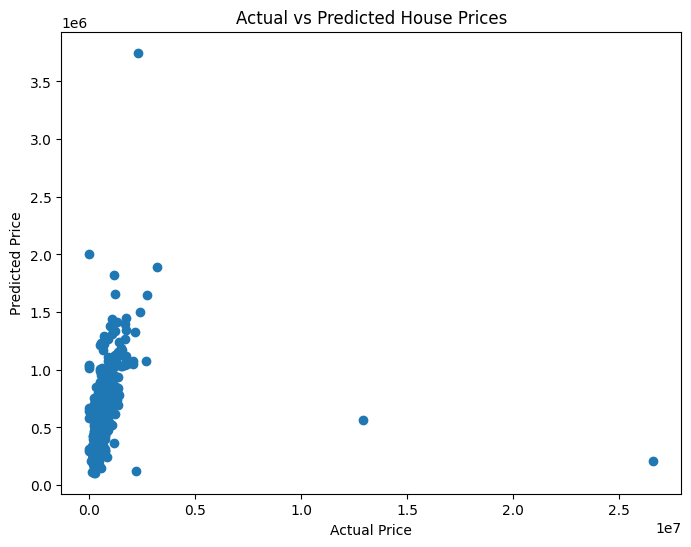

In [27]:
# =========================
# Coefficients
# =========================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\n========== COEFFICIENTS ==========")
print(coef_df.sort_values(by="Coefficient", ascending=False))

print("\nIntercept:")
print(model.intercept_)

# =========================
# Actual vs Predicted Plot
# =========================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()


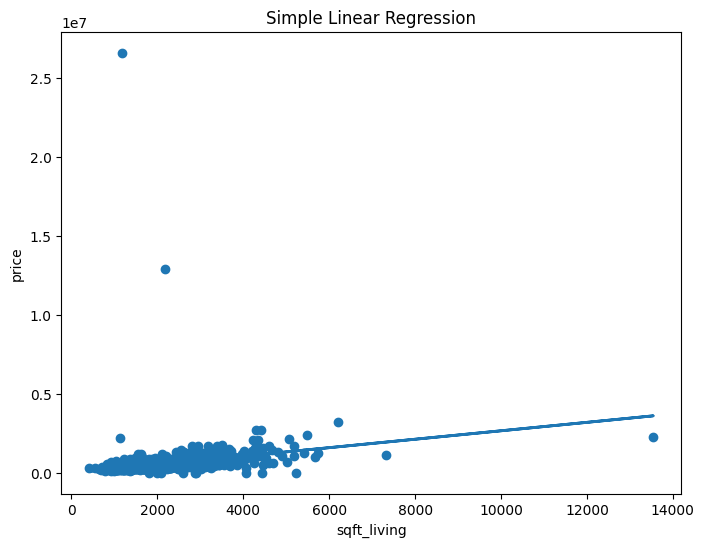

In [28]:

# =========================
# Simple Linear Regression
# =========================

X_simple = df[["sqft_living"]]
y_simple = df["price"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

simple_model = LinearRegression()

simple_model.fit(X_train_s, y_train_s)

y_pred_s = simple_model.predict(X_test_s)

plt.figure(figsize=(8,6))
plt.scatter(X_test_s, y_test_s)

plt.plot(X_test_s, y_pred_s, linewidth=2)

plt.xlabel("sqft_living")
plt.ylabel("price")
plt.title("Simple Linear Regression")

plt.show()



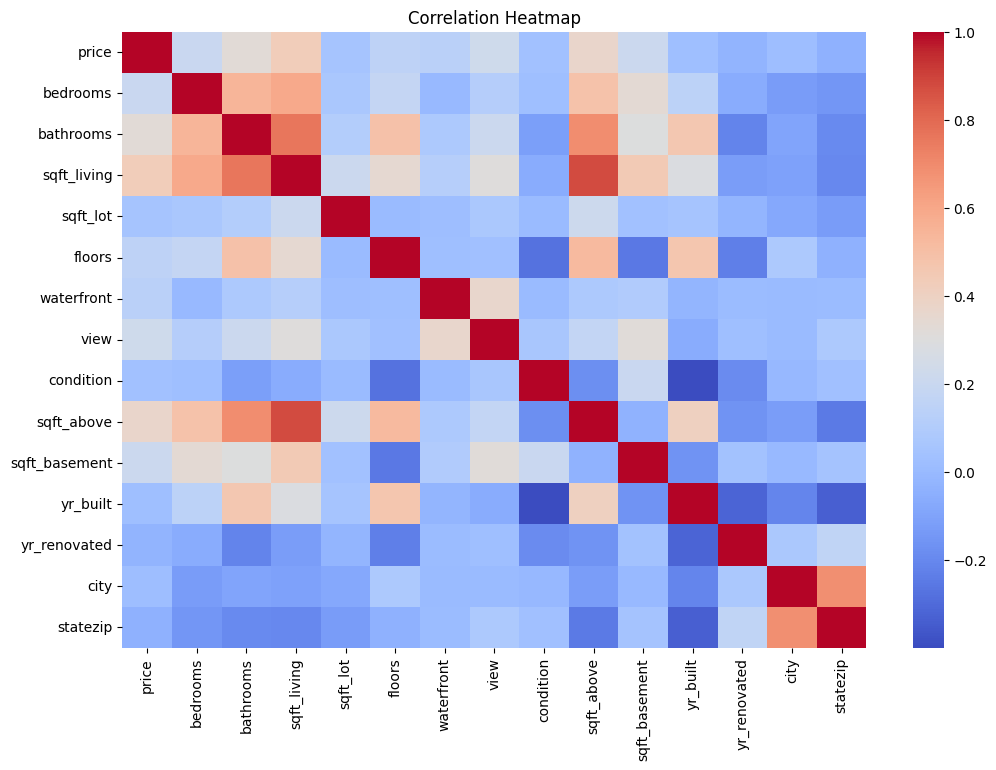


========== SAMPLE PREDICTIONS ==========
   Actual Price  Predicted Price
0  5.440000e+05     3.056626e+05
1  0.000000e+00     3.117828e+05
2  1.712500e+06     1.081407e+06
3  3.650000e+05     5.707895e+05
4  2.750000e+05     3.834782e+05
5  6.250000e+05     5.928231e+05
6  4.530000e+05     4.603857e+05
7  3.000000e+05     4.200372e+05
8  4.179857e+05     5.094399e+05
9  6.725000e+05     5.386652e+05


In [29]:
# =========================
# Correlation Heatmap
# =========================

import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================
# Sample Predictions
# =========================

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\n========== SAMPLE PREDICTIONS ==========")
print(results.head(10))